# Lesson 22: unsupervised learning demonstration

This notebook demonstrates key concepts and tools for training unsupervised models.

1. Clustering
    - Kmeans
    - Hierarchical
    - DBSCAN
    - Clustering evaluation
    - Determining cluster number

2. Dimensionality reduction
    - PCA
    - Feature Agglomeration
    - t-SNE

3. Anomaly detection
4. Association rule learning


## Notebook set up

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import make_blobs, fetch_kddcup99
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.cluster import FeatureAgglomeration
from sklearn.metrics import silhouette_score, precision_score, recall_score, f1_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from scipy.cluster.hierarchy import dendrogram, linkage

### Dataset

The notebook uses a synthetic dataset of 1,000 points generated by `make_blobs`, which places samples around a fixed number of cluster centres in 2D feature space. Using synthetic data makes it easy to visually verify that each algorithm has found the correct groupings. The same dataset is reused across the clustering and anomaly detection sections; a noisier 10-feature version is derived from it for the dimensionality reduction section.

In [2]:
# Number of clusters
n_clusters = 3

# Generate synthetic dataset
data = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=n_clusters,
    cluster_std=0.6,
    random_state=0
)

# Create dataframe with feature columns
df = pd.DataFrame(data[0], columns=[f'feature_{i}' for i in range(data[0].shape[1])])

# Standard scale the features
scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df[df.columns])
df.head()

,feature_0,feature_1
0,-0.972185,0.046031
1,0.652719,0.999023
2,-1.227944,0.217025
3,-1.083584,0.128545
4,-1.608505,-0.250835


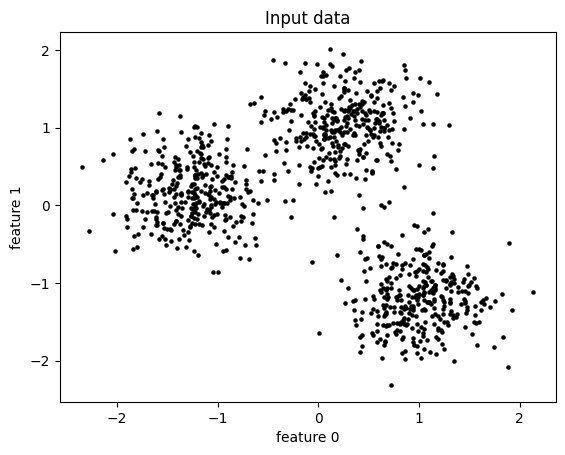

In [3]:
plt.title('Input data')
plt.scatter(df['feature_0'], df['feature_1'], s=5, c='black')
plt.xlabel('feature 0')
plt.ylabel('feature 1')
plt.show()

## 1. Clustering

### 1.1. KMeans

KMeans partitions data into k clusters by minimizing within-cluster variance. Each cluster is represented by its centroid.

A **centroid** is the average position of all points in a cluster: the point you would land on if you averaged every feature across every member of the cluster. For cluster $C_k$ with $|C_k|$ points:

$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x_i$$

For example, if a cluster contains points $(1, 2)$, $(3, 4)$ and $(5, 6)$, its centroid is $\left(\frac{1+3+5}{3},\, \frac{2+4+6}{3}\right) = (3, 4)$.

- Choose a value for k (the number of clusters).
- Place k centroids at random positions in the feature space.
- Assign each point to the nearest centroid.
- Recalculate each centroid as the mean of its assigned points.
- Repeat the assignment and update steps until centroids stop moving.

Scikit-learn [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) implementation

In [4]:
# Fit KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=315)
kmeans_labels = kmeans.fit_predict(df)

# Calculate metrics
kmeans_silhouette = silhouette_score(df, kmeans_labels)

print(f'KMeans - Silhouette: {kmeans_silhouette:.3f}')

KMeans - Silhouette: 0.652


### 1.2. Hierarchical clustering

Hierarchical clustering builds a tree of clusters by merging clusters based on distance metrics.

- Start with every point as its own cluster.
- Find the two clusters closest to each other using a chosen linkage metric (e.g. Ward).
- Merge those two clusters into one.
- Repeat until the desired number of clusters remains.
- The result can be visualized as a dendrogram showing the merge order.

**Linkage metrics** determine how the distance between two clusters is calculated:

| Linkage | Distance between clusters |
|---------|--------------------------|
| Single | Shortest distance between any two points across the clusters |
| Complete | Longest distance between any two points across the clusters |
| Average | Mean distance between all pairs of points across the clusters |
| Ward | Increase in total within-cluster variance from merging |

**Ward linkage** merges the pair of clusters that causes the smallest increase in total within-cluster variance. This tends to produce compact, evenly sized clusters and is the most commonly used linkage method.

Scikit-learn [Agglomerative Clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) implementation

In [5]:
# Fit hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_labels = hierarchical.fit_predict(df)

# Calculate metrics
hierarchical_silhouette = silhouette_score(df, hierarchical_labels)

print(f'Hierarchical - Silhouette: {hierarchical_silhouette:.3f}')

Hierarchical - Silhouette: 0.648


### 1.3. DBSCAN

DBSCAN groups points that are closely packed together, marking points in low-density regions as outliers. It does not require specifying the number of clusters.

- Choose a radius `eps` and a minimum neighbor count `min_samples`.
- Label a point as a **core point** if at least `min_samples` other points fall within radius `eps` of it.
- A neighbor of a core point is called **reachable**. Reachability chains: if B is within `eps` of core point A, and C is within `eps` of core point B, then A, B and C all belong to the same cluster, even if A and C are far apart.
- Grow each cluster by following these chains until no new reachable points remain.
- Points that are not within `eps` of any core point are labeled as noise (outliers).

The number of clusters is determined by how many separate chains exist in the data, not by how many points each chain contains.

| Parameter | Effect |
|-----------|--------|
| `eps` | Larger values extend chains further, merging more points into the same cluster |
| `min_samples` | Higher values require denser cores, which can break weak chains into noise |

Scikit-learn [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) implementation

In [6]:
# Fit DBSCAN clustering
eps = 0.16
dbscan = DBSCAN(eps=eps)
dbscan_labels = dbscan.fit_predict(df)

# Count clusters (excluding noise points labeled as -1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'DBSCAN found {n_clusters} clusters and {n_noise} noise points')

# Calculate metrics (excluding noise points)
mask = dbscan_labels != -1
dbscan_silhouette = silhouette_score(df[mask], dbscan_labels[mask])

print(f'DBSCAN - Silhouette: {dbscan_silhouette:.3f}')

DBSCAN found 3 clusters and 72 noise points
DBSCAN - Silhouette: 0.683


### 1.4. Clustering evaluation

#### 1.4.1. Silhouette score

The silhouette score measures how similar a data point is to its own cluster compared to other clusters. For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

Where $a(i)$ is the mean distance from point $i$ to all other points in its own cluster, and $b(i)$ is the mean distance from point $i$ to all points in the nearest other cluster.

The overall score is the mean of $s(i)$ across all points. It ranges from -1 to 1: a high value means points are well matched to their own cluster and far from others; a score near 0 indicates overlapping clusters; negative values suggest a point may be in the wrong cluster.

In [7]:
# Create comparison dataframe
clustering_results = pd.DataFrame({
    'Method': ['KMeans', 'Hierarchical', 'DBSCAN'],
    'Silhouette': [kmeans_silhouette, hierarchical_silhouette, dbscan_silhouette]
})

clustering_results

,Method,Silhouette
0,KMeans,0.652014
1,Hierarchical,0.647966
2,DBSCAN,0.682974


#### 1.4.2. Scatter plots

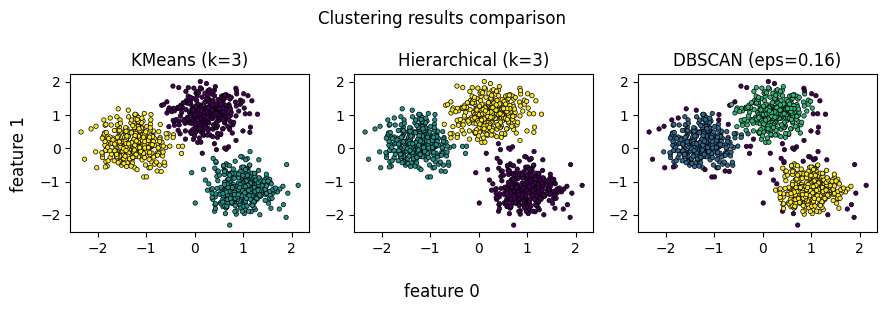

In [8]:
ncols = 3
nrows = 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3))

fig.suptitle('Clustering results comparison')
fig.supxlabel('feature 0')
fig.supylabel('feature 1')

# KMeans
axes[0].scatter(df['feature_0'], df['feature_1'], c=kmeans_labels, s = 10, edgecolors='black', linewidth=0.5)
axes[0].set_title(f'KMeans (k={n_clusters})')

# Hierarchical
axes[1].scatter(df['feature_0'], df['feature_1'], c=hierarchical_labels, s = 10, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'Hierarchical (k={n_clusters})')

# DBSCAN
axes[2].scatter(df['feature_0'], df['feature_1'], c=dbscan_labels, s = 10, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'DBSCAN (eps={eps})')

plt.tight_layout()
plt.show()

#### 1.4.3. Dendrogram (hierarchical clustering only)

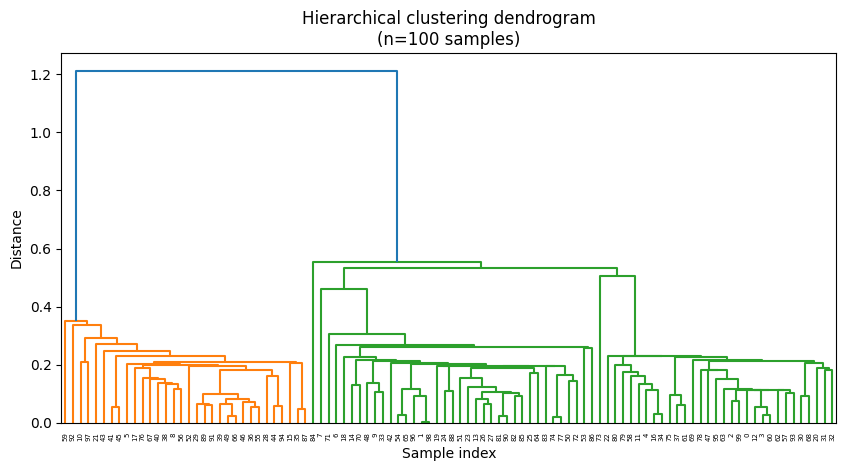

In [9]:
# Create dendrogram
linkage_matrix = linkage(df.iloc[:100])

plt.figure(figsize=(10, 4.8))
dendrogram(linkage_matrix)
plt.title('Hierarchical clustering dendrogram\n(n=100 samples)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

### 1.5. Determining cluster number

#### 1.5.1. Elbow method

The elbow method helps determine the optimal number of clusters by plotting the within-cluster sum of squares (inertia) for different values of k. The optimal k is at the 'elbow' where the rate of decrease sharply changes.

Inertia is the total squared distance from each point to its cluster centroid:

$$\text{Inertia} = \sum_{k=1}^{K} \sum_{i \in C_k} \|x_i - \mu_k\|^2$$

Where $x_i$ is a point in cluster $C_k$ and $\mu_k$ is the centroid of that cluster. Inertia always decreases as k increases, so the goal is to find the point where adding more clusters gives diminishing returns.

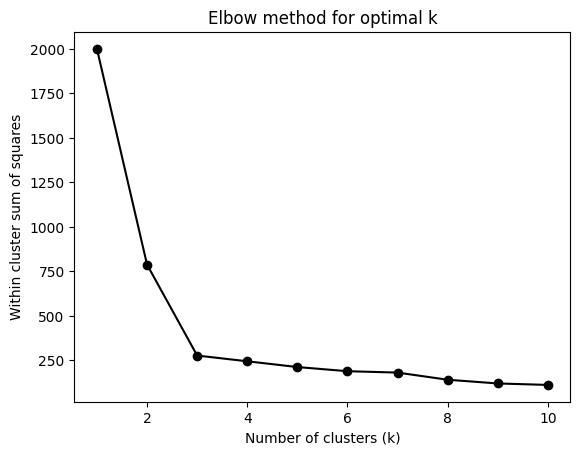

In [10]:
# Calculate inertia for different numbers of clusters
k_range = range(1, 11)
inertias = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=315)
    kmeans_temp.fit(df)
    inertias.append(kmeans_temp.inertia_)

# Plot elbow curve
plt.plot(k_range, inertias, marker='o', color='black')
plt.title('Elbow method for optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within cluster sum of squares')
plt.show()

#### 1.5.2. Silhouette analysis

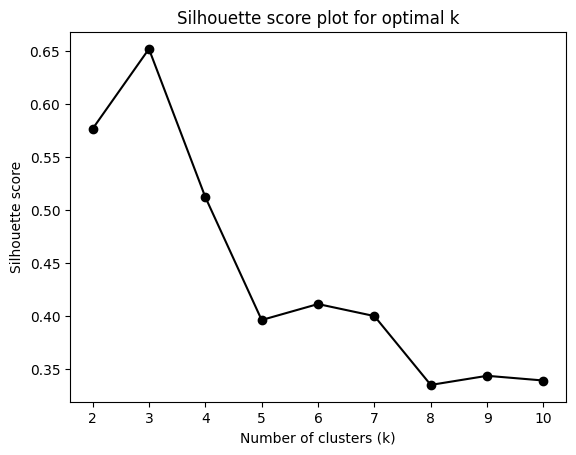

In [11]:
# Calculate silhouette score for different numbers of clusters
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:

    kmeans_temp = KMeans(n_clusters=k, random_state=315)
    labels = kmeans_temp.fit_predict(df)
    silhouette_scores.append(silhouette_score(df, labels))

# Plot silhouette curve
plt.plot(k_range, silhouette_scores, marker='o', color='black')
plt.title('Silhouette score plot for optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.show()

## 2. Dimensionality reduction

### 2.1. High dimensional dataset

To demonstrate dimensionality reduction techniques, we will 'hide' the cluster signal from our two original features in a larger set of noisy features. Then we will apply dimensionality reduction to try and recover the original signal.

In [12]:
# Create high dimensional dataset by multiplying each feature with random noise
# a number of times, results in a set of features that contain the cluster signal
# hidden among noisy features
n_features = 10
noise_range = (-1.25, 1.25)
noise_features = {}

for feature in df.columns:

    for j in range(n_features // len(df.columns)):

        noise = np.random.uniform(low=noise_range[0], high=noise_range[1], size=len(df))
        noise_features[f'{feature}_noise_{j}'] = df[feature] + noise

# Create new dataframe with 10 features
noise_df = pd.DataFrame(noise_features)

print(f'Original dataset shape: {df.shape}')
print(f'High dimensional dataset shape: {noise_df.shape}')
noise_df.head()

Original dataset shape: (1000, 2)
High dimensional dataset shape: (1000, 10)


,feature_0_noise_0,feature_0_noise_1,feature_0_noise_2,feature_0_noise_3,feature_0_noise_4,feature_1_noise_0,feature_1_noise_1,feature_1_noise_2,feature_1_noise_3,feature_1_noise_4
0,-0.851596,-0.974346,-1.648465,-0.292339,-1.077955,-0.854047,-0.811732,0.978294,0.633805,-0.520205
1,-0.423278,1.154441,0.412045,-0.427351,0.477508,-0.146290,0.588432,0.864924,2.014352,1.792080
2,-1.725746,-0.602883,-2.173106,-1.386890,-1.195081,0.156708,-0.173057,1.079776,0.407480,0.473172
3,-2.074254,-1.644813,-1.103451,-0.700618,-1.241018,0.158105,-1.026380,0.998867,0.700117,1.183262
4,-1.482179,-1.250161,-1.010450,-2.699164,-2.450510,0.077572,0.838238,-1.325050,-0.006412,-1.080975


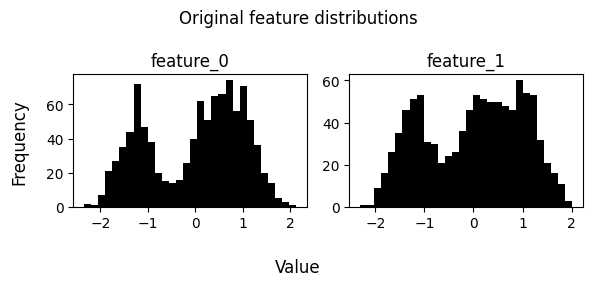

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(6, 2.75))

fig.suptitle('Original feature distributions')
fig.supxlabel('Value')
fig.supylabel('Frequency')

# Original data
for i, feature in enumerate(df.columns):
    axs[i].set_title(f'{feature}')
    axs[i].hist(df[feature], bins=30, color='black')

plt.tight_layout()
plt.show()

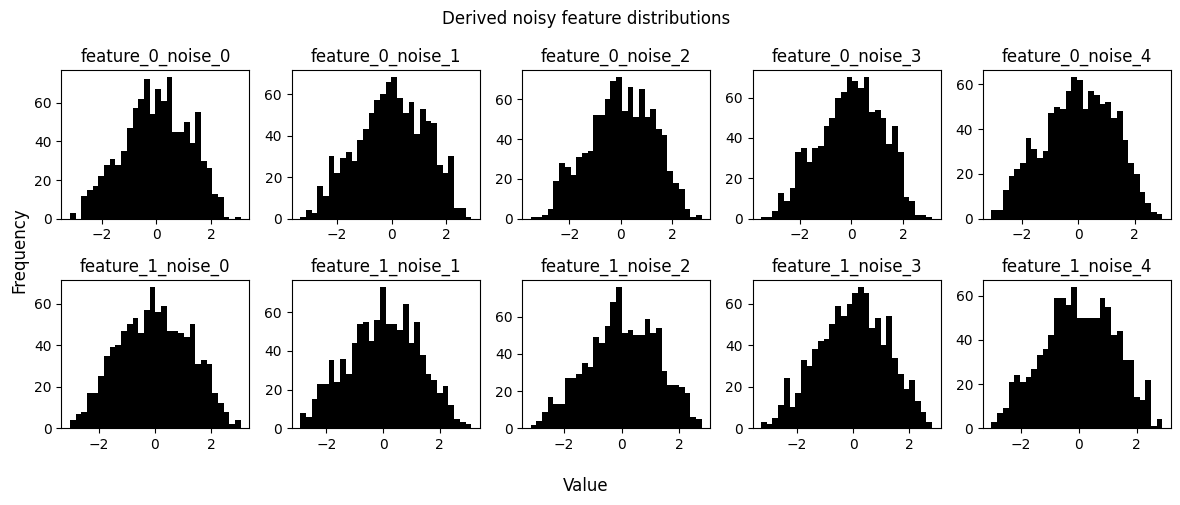

In [14]:
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
axs = axs.flatten()

fig.suptitle('Derived noisy feature distributions')
fig.supxlabel('Value')
fig.supylabel('Frequency')

# Original data
for i, feature in enumerate(noise_df.columns):
    axs[i].set_title(f'{feature}')
    axs[i].hist(noise_df[feature], bins=30, color='black')

plt.tight_layout()
plt.show()

In [15]:
output_features = 2
scaler = StandardScaler()

### 2.2. PCA

Principal Component Analysis finds new axes (principal components) that capture the most variance in the data. Each component is a linear combination of the original features, ordered so the first component explains the most variance, the second the next most, and so on.

**Covariance matrix**

For a 2-feature dataset, the covariance matrix summarises how each pair of features varies together:

$$\Sigma = \begin{bmatrix} \text{Var}(x_1) & \text{Cov}(x_1, x_2) \\ \text{Cov}(x_1, x_2) & \text{Var}(x_2) \end{bmatrix}$$

For example, if both features have variance 2 and covariance 1:

$$\Sigma = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$$

**Eigenvectors and eigenvalues**

The $k$-th principal component is the eigenvector $v_k$ satisfying:

$$\Sigma v_k = \lambda_k v_k$$

Where $\lambda_k$ is the eigenvalue: the variance explained by that component. For the example above, solving gives $\lambda_1 = 3$ and $v_1 = [0.71,\, 0.71]^T$. We can verify:

$$\begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} \begin{bmatrix} 0.71 \\ 0.71 \end{bmatrix} = \begin{bmatrix} 2.12 \\ 2.12 \end{bmatrix} = 3 \times \begin{bmatrix} 0.71 \\ 0.71 \end{bmatrix}$$

The eigenvector $[0.71, 0.71]^T$ has equal values in both dimensions, which means it points equally in the $x_1$ and $x_2$ directions at 45° from either axis.

A point $x$ is projected onto the top $k$ components to get its reduced representation:

$$z = V_k^T (x - \bar{x})$$

Where $V_k$ is the matrix of the top $k$ eigenvectors and $\bar{x}$ is the feature mean.

- Centre the data by subtracting the mean of each feature.
- Compute the covariance matrix of the centred features.
- Find its eigenvectors and eigenvalues.
- Order components by decreasing eigenvalue.
- Project the data onto the top $k$ components.

Scikit-learn [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) implementation

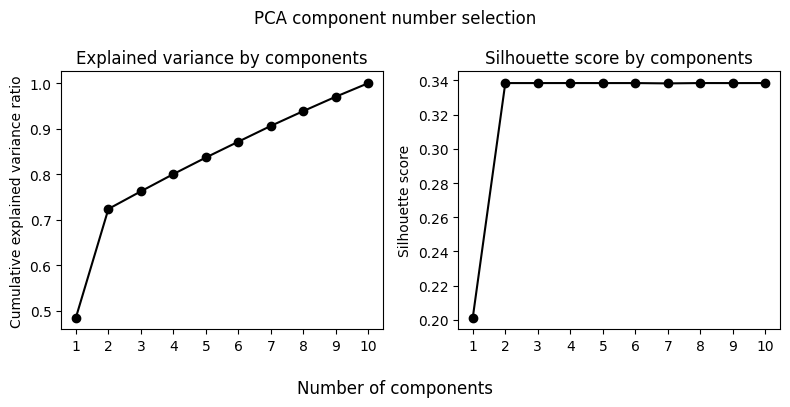

In [16]:
# Evaluate cumulative explained variance across a range of component numbers
comp_range = range(1, 11)
cumulative_variance = []
silhouette_scores = []

for n_comp in comp_range:

    pca_temp = PCA(n_components=n_comp, random_state=315)
    pca_temp.fit(noise_df)
    cumulative_variance.append(np.sum(pca_temp.explained_variance_ratio_))

    kmeans_temp = KMeans(n_clusters=3, random_state=315)
    kmeans_labels_temp = kmeans_temp.fit_predict(pca_temp.transform(noise_df))
    silhouette_scores.append(silhouette_score(noise_df, kmeans_labels_temp))

# Plot cumulative explained variance
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

fig.suptitle('PCA component number selection')
fig.supxlabel('Number of components')

axs[0].set_title('Explained variance by components')
axs[0].plot(comp_range, cumulative_variance, marker='o', color='black')
axs[0].set_ylabel('Cumulative explained variance ratio')
axs[0].set_xticks(comp_range)

axs[1].set_title('Silhouette score by components')
axs[1].plot(comp_range, silhouette_scores, marker='o', color='black')
axs[1].set_ylabel('Silhouette score')
axs[1].set_xticks(comp_range)

plt.tight_layout()
plt.show()

In [17]:
# Apply PCA
pca = PCA(n_components=output_features, random_state=315)
X_pca = pca.fit_transform(noise_df)

pca_df = pd.DataFrame(X_pca, columns=pca.get_feature_names_out())
pca_df.head()

,pca0,pca1
0,-1.330440,-1.720132
1,-1.160788,2.026709
2,-2.812456,-1.599557
3,-2.718501,-1.421573
4,-2.347373,-3.289073


### 2.3. Feature agglomeration

Feature agglomeration applies hierarchical clustering to the features (columns) rather than the samples (rows). Features that behave similarly across samples are grouped together and replaced by a single aggregate, reducing the number of dimensions while preserving as much structure as possible.

- Treat each feature as a point in sample space.
- Compute pairwise similarities between features.
- Merge the most similar pair of features into one cluster using Ward linkage (see section 1.2).
- Repeat until the desired number of feature groups remains.
- Replace each group with a single representative value (mean of the group).

Scikit-learn [FeatureAgglomeration](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.FeatureAgglomeration.html) implementation

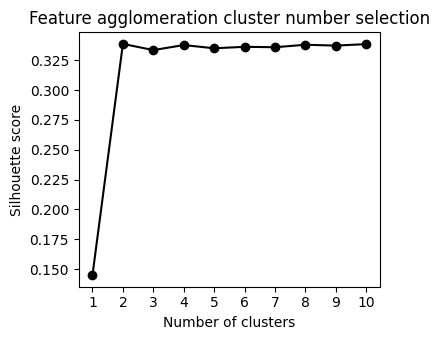

In [18]:
# Evaluate silhouette score across a range of agglomeration cluster numbers
cluster_range = range(1, 11)
silhouette_scores = []

for n_clusters in cluster_range:

    agg_temp = FeatureAgglomeration(n_clusters=n_clusters)
    agg_temp.fit(noise_df)

    kmeans_temp = KMeans(n_clusters=3, random_state=315)
    kmeans_labels_temp = kmeans_temp.fit_predict(agg_temp.transform(noise_df))
    silhouette_scores.append(silhouette_score(noise_df, kmeans_labels_temp))

# Plot cumulative explained variance
plt.figure(figsize=(4, 3.5))
plt.title('Feature agglomeration cluster number selection')
plt.plot(cluster_range, silhouette_scores, marker='o', color='black')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.xticks(cluster_range)

plt.tight_layout()
plt.show()

In [19]:
# Apply Feature Agglomeration
fa = FeatureAgglomeration(n_clusters=output_features)
X_fa = fa.fit_transform(noise_df)

# Create FA dataframe
fa_df = pd.DataFrame(X_fa, columns=[f'FA{i+1}' for i in range(output_features)])
fa_df.head()

,FA1,FA2
0,-0.968940,-0.114777
1,0.238673,1.022700
2,-1.416741,0.388816
3,-1.352831,0.402794
4,-1.778493,-0.299325


### 2.4. Truncated SVD

Truncated SVD decomposes the data matrix into three matrices and keeps only the top $k$ components of each, similar to PCA but without centring the data first. This makes it suitable for sparse matrices where centring would destroy sparsity.

Any matrix $X$ with $n$ rows (observations) and $p$ columns (features) can be written as:

$$X = U \Sigma V^T$$

| Matrix | Shape | What it represents |
|--------|-------|--------------------|
| $X$ | $n \times p$ | The original data: $n$ observations, each with $p$ features |
| $U$ | $n \times n$ | One row per observation; each column is a left singular vector describing how observations relate to a component |
| $\Sigma$ | $n \times p$ | Diagonal matrix of singular values, ordered largest to smallest |
| $V^T$ | $p \times p$ | One column per feature (transposed: one row per feature); each row is a right singular vector describing how features relate to a component |

**Singular values** are the values $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$ along the single main diagonal of $\Sigma$, with zeros everywhere else:

$$\Sigma = \begin{bmatrix} \sigma_1 & 0 & \cdots \\ 0 & \sigma_2 & \cdots \\ \vdots & \vdots & \ddots \end{bmatrix}$$

Each singular value measures how much of the data's total variation is captured by that component: a large value means that component explains a lot of structure, a small one means it captures mostly noise.

**Singular vectors** come in pairs. For the $i$-th component:
- $\sigma_i$ is a **scalar**: the single value at position $(i, i)$ in $\Sigma$.
- $v_i$ is **column $i$ of $V$** (equivalently, **row $i$ of $V^T$**): a $p$-element vector, one entry per feature, pointing in the direction of the $i$-th component in feature space.
- $u_i$ is **column $i$ of $U$**: an $n$-element vector, one entry per observation, giving each observation's score on the $i$-th component.

Together they satisfy:

$$X v_i = \sigma_i u_i \qquad X^T u_i = \sigma_i v_i$$

This is the SVD analogue of the eigenvector equation from PCA: instead of one vector rotating into a scaled version of itself, a pair of vectors map back and forth through the data matrix.

**Truncated version:** keep only the top $k$ components, so the three matrices shrink accordingly:

| Matrix | Full shape | Truncated shape |
|--------|------------|-----------------|
| $U_k$ | $n \times n$ | $n \times k$ |
| $\Sigma_k$ | $n \times p$ | $k \times k$ |
| $V_k^T$ | $p \times p$ | $k \times p$ |

$$X \approx U_k \Sigma_k V_k^T$$

- Decompose $X$ into $U$, $\Sigma$, and $V^T$.
- Keep the $k$ largest singular values and their corresponding vectors.
- Project the data onto the reduced space: $Z = X V_k$, giving an $n \times k$ output.

Scikit-learn [TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) implementation

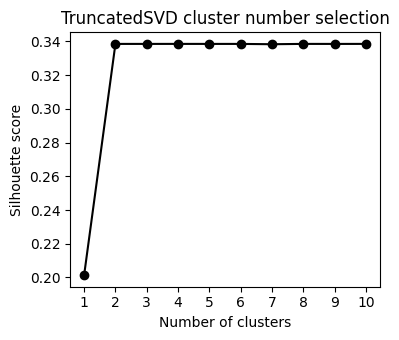

In [20]:
# Evaluate silhouette score across a range of agglomeration cluster numbers
cluster_range = range(1, 11)
silhouette_scores = []

for n_clusters in cluster_range:

    svd_temp = TruncatedSVD(n_components=n_clusters)
    svd_temp.fit(noise_df)

    kmeans_temp = KMeans(n_clusters=3, random_state=315)
    kmeans_labels_temp = kmeans_temp.fit_predict(svd_temp.transform(noise_df))
    silhouette_scores.append(silhouette_score(noise_df, kmeans_labels_temp))

# Plot cumulative explained variance
plt.figure(figsize=(4, 3.5))
plt.title('TruncatedSVD cluster number selection')
plt.plot(cluster_range, silhouette_scores, marker='o', color='black')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.xticks(cluster_range)

plt.tight_layout()
plt.show()

In [21]:
# Apply Truncated SVD
svd = TruncatedSVD(n_components=output_features)
X_svd = svd.fit_transform(noise_df)

# Create SVD dataframe
svd_df = pd.DataFrame(X_svd, columns=[f'SVD{i+1}' for i in range(output_features)])
svd_df.head()

,SVD1,SVD2
0,-1.350897,-1.738110
1,-1.180939,2.008584
2,-2.832965,-1.617512
3,-2.739050,-1.439651
4,-2.367994,-3.306970


### 2.5. t-SNE

t-SNE is a nonlinear dimensionality reduction technique designed for visualization. It preserves local structure by modelling pairwise similarities between points as probabilities, then finding a low-dimensional layout that matches those probabilities as closely as possible.

- Compute pairwise similarity between all points in the high-dimensional space using a Gaussian kernel: nearby points get high similarity, distant points get low similarity.
- Initialize points randomly in the low-dimensional space.
- Compute pairwise similarity in the low-dimensional space.
- Move points iteratively until the low-dimensional similarity distribution matches the high-dimensional one as closely as possible.

**Note:** t-SNE is primarily a visualization tool. The axes have no interpretable meaning, and distances between clusters in the output are not reliable for quantitative analysis.

Scikit-learn [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) implementation

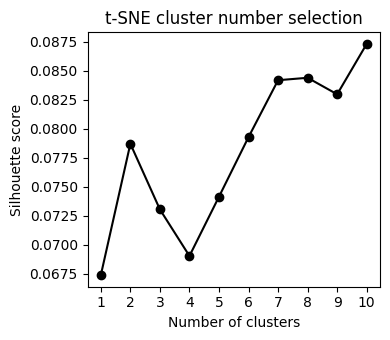

In [22]:
# Evaluate silhouette score across a range of component numbers
components_range = range(1, 11)
silhouette_scores = []

for n_components in components_range:

    tsne_temp = TSNE(n_components=n_components, method='exact', random_state=315)
    kmeans_temp = KMeans(n_clusters=n_clusters, random_state=315)
    kmeans_labels_temp = kmeans_temp.fit_predict(tsne_temp.fit_transform(noise_df))
    silhouette_scores.append(silhouette_score(noise_df, kmeans_labels_temp))

# Plot cumulative explained variance
plt.figure(figsize=(4, 3.5))
plt.title('t-SNE cluster number selection')
plt.plot(components_range, silhouette_scores, marker='o', color='black')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.xticks(components_range)

plt.tight_layout()
plt.show()

In [23]:
# Apply t-SNE
tsne = TSNE(n_components=output_features, method='exact', random_state=315)
X_tsne = tsne.fit_transform(noise_df)

# Create t-SNE dataframe
tsne_df = pd.DataFrame(X_tsne, columns=[f'TSNE{i+1}' for i in range(output_features)])
tsne_df.head()

,TSNE1,TSNE2
0,-35.256859,-15.693397
1,-0.653823,13.309549
2,-37.350857,-1.786574
3,-34.544605,-10.192158
4,-42.284966,-12.237552


### 2.6. Dimensionality reduction comparison

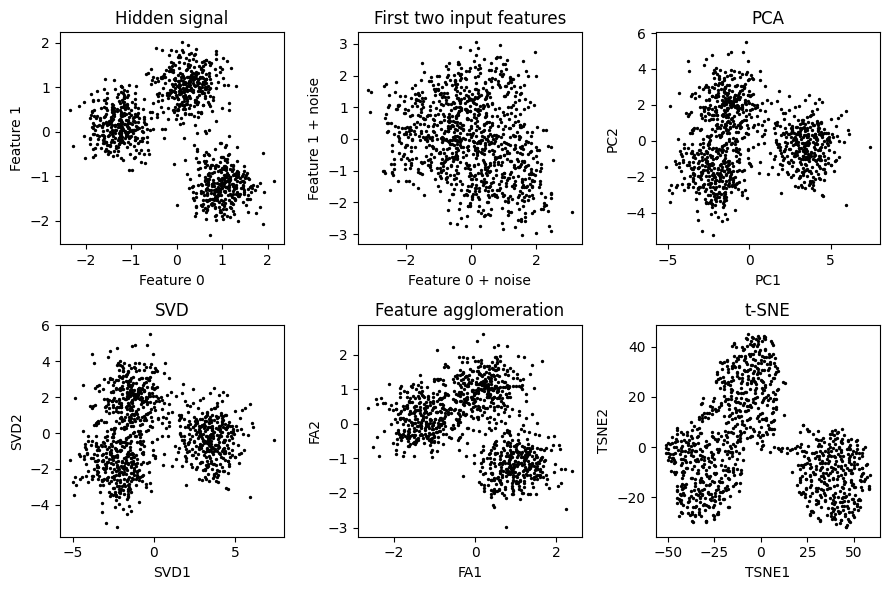

In [24]:
ncols = 3
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3))
axes = axes.flatten()

# Input signal
axes[0].set_title('Hidden signal')
axes[0].scatter(df['feature_0'], df['feature_1'], c='black', s=2)
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Feature 1')

# Input features
axes[1].set_title('First two input features')
axes[1].scatter(noise_df['feature_0_noise_0'], noise_df['feature_1_noise_0'], c='black', s=2)
axes[1].set_xlabel('Feature 0 + noise')
axes[1].set_ylabel('Feature 1 + noise')

# PCA
axes[2].set_title('PCA')
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c='black', s=2)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

# SVD
axes[3].set_title('SVD')
axes[3].scatter(X_svd[:, 0], X_svd[:, 1], c='black', s=2)
axes[3].set_xlabel('SVD1')
axes[3].set_ylabel('SVD2')

# Feature Agglomeration
axes[4].set_title('Feature agglomeration')
axes[4].scatter(X_fa[:, 0], X_fa[:, 1], c='black', s=2)
axes[4].set_xlabel('FA1')
axes[4].set_ylabel('FA2')

# t-SNE
axes[5].set_title('t-SNE')
axes[5].scatter(X_tsne[:, 0], X_tsne[:, 1], c='black', s=2)
axes[5].set_xlabel('TSNE1')
axes[5].set_ylabel('TSNE2')

plt.tight_layout()
plt.show()

### 2.7. A note about LDA

LDA (linear discriminant analysis) is a supervised algorithm, so it doesn't really fit in this lesson - but if you have labels and want to do dimensionality reduction, it can be a great option!

In [25]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_df = noise_df.copy()
lda_df['label'] = kmeans_labels

lda = LinearDiscriminantAnalysis(n_components=2)
lda_features = lda.fit_transform(lda_df.drop(columns='label'), lda_df['label'])
lda_df = pd.DataFrame(lda_features, columns=lda.get_feature_names_out())
lda_df.head()

,lineardiscriminantanalysis0,lineardiscriminantanalysis1
0,1.178466,-1.450777
1,0.965496,1.921375
2,2.532027,-1.333087
3,2.498680,-1.282677
4,2.288654,-3.010180


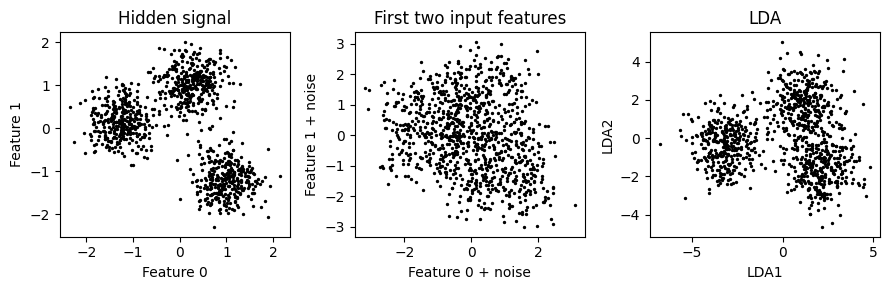

In [26]:
ncols = 3
nrows = 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3))

# Input signal
axes[0].set_title('Hidden signal')
axes[0].scatter(df['feature_0'], df['feature_1'], c='black', s=2)
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Feature 1')

# Input features
axes[1].set_title('First two input features')
axes[1].scatter(noise_df['feature_0_noise_0'], noise_df['feature_1_noise_0'], c='black', s=2)
axes[1].set_xlabel('Feature 0 + noise')
axes[1].set_ylabel('Feature 1 + noise')

# LDA
axes[2].set_title('LDA')
axes[2].scatter(lda_df.values[:, 0], lda_df.values[:, 1], c='black', s=2)
axes[2].set_xlabel('LDA1')
axes[2].set_ylabel('LDA2')

plt.tight_layout()
plt.show()

## 3. Anomaly detection

### 3.1. Dataset

This section uses the [KDD Cup 1999 network intrusion dataset](https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html), a benchmark dataset built from simulated network traffic. Each row is one network connection described by 41 features: 38 numerical (e.g. duration, bytes transferred, number of failed login attempts) and 3 categorical (protocol type, network service, and connection flag). Connections are labeled either `normal` or as one of several attack types.

Although labels exist, we treat this as an **unsupervised** problem: all four models are trained on features only, with no access to labels. This mirrors the real-world scenario where some labeled historical anomalies may exist for evaluation, but the model must detect new anomalous network traffic without supervision. Labels are revealed only in section 3.6 to evaluate results.

The dataset is subsampled to 2,000 connections (1,800 normal, 200 attacks) to keep runtimes manageable across all methods. The `contamination` parameter is set to 0.10 to match the known anomaly rate of the sample.

In [47]:
kdd = fetch_kddcup99(percent10=True, random_state=315)

kdd_df = pd.DataFrame(kdd.data, columns=kdd.feature_names)
kdd_df['label'] = kdd.target

# Binarize labels before modifying the dataframe
y_all = (kdd_df.pop('label') != b'normal.').astype(int)

# Cast numerical features; one-hot encode the 3 categorical columns
cat_features = ['protocol_type', 'service', 'flag']
num_features = [c for c in kdd.feature_names if c not in cat_features]
kdd_df[num_features] = kdd_df[num_features].apply(pd.to_numeric, errors='coerce')
kdd_df = pd.get_dummies(kdd_df, columns=cat_features)

# Subsample: 1800 normal + 200 attack to give a 10% anomaly rate
normal_idx = y_all[y_all == 0].sample(1800, random_state=315).index
attack_idx = y_all[y_all == 1].sample(200, random_state=315).index
sample_idx = normal_idx.union(attack_idx)

X = kdd_df.loc[sample_idx].reset_index(drop=True)
y_true = y_all.loc[sample_idx].reset_index(drop=True)

# Scale features, labels are set aside and not used during training
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

contamination = 0.1

print(f'Dataset: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features')
print(f'True anomaly rate: {y_true.mean():.1%}')
X_scaled.head()

Dataset: 2000 samples, 118 features
True anomaly rate: 10.0%


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_b'REJ',flag_b'RSTO',flag_b'RSTOS0',flag_b'RSTR',flag_b'S0',flag_b'S1',flag_b'S2',flag_b'S3',flag_b'SF',flag_b'SH'
0,-0.147968,-0.029682,-0.187378,0.0,-0.022366,0.0,-0.052208,0.0,0.739453,-0.038759,...,-0.219586,-0.044766,0.0,0.0,-0.149983,0.0,0.0,0.0,0.274352,0.0
1,-0.147968,-0.029214,1.058024,0.0,-0.022366,0.0,-0.052208,0.0,0.739453,-0.038759,...,-0.219586,-0.044766,0.0,0.0,-0.149983,0.0,0.0,0.0,0.274352,0.0
2,-0.147968,-0.029764,-0.074959,0.0,-0.022366,0.0,-0.052208,0.0,0.739453,-0.038759,...,-0.219586,-0.044766,0.0,0.0,-0.149983,0.0,0.0,0.0,0.274352,0.0
3,-0.147968,-0.027850,0.452908,0.0,-0.022366,0.0,-0.052208,0.0,0.739453,-0.038759,...,-0.219586,-0.044766,0.0,0.0,-0.149983,0.0,0.0,0.0,0.274352,0.0
4,-0.147968,-0.028786,1.795656,0.0,-0.022366,0.0,-0.052208,0.0,0.739453,-0.038759,...,-0.219586,-0.044766,0.0,0.0,-0.149983,0.0,0.0,0.0,0.274352,0.0


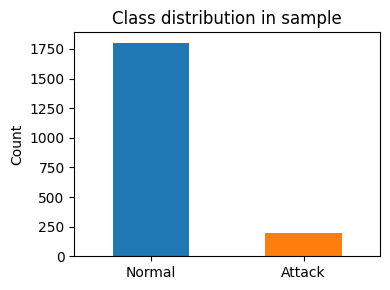

In [48]:
counts = pd.Series({'Normal': (y_true == 0).sum(), 'Attack': (y_true == 1).sum()})

counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'], figsize=(4, 3))
plt.title('Class distribution in sample')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2. Robust covariance (elliptic envelope)

Robust covariance estimation assumes the inlier data follows a multivariate Gaussian distribution. It fits a robust estimate of the covariance matrix and uses the Mahalanobis distance to measure how far each point is from the data center. Points beyond a threshold are flagged as anomalies.

- Estimate the center and covariance of the data using a method that down-weights likely outliers.
- Compute the Mahalanobis distance from each point to the center: $d(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}$.
- Flag points whose distance exceeds the threshold set by `contamination`.

Key hyperparameter: `contamination` (expected fraction of anomalies).

Note: the covariance matrix must be full rank. One-hot encoded columns are linearly dependent (each group of indicator columns sums to 1 across every row), which makes the covariance matrix singular regardless of sample size. PCA is applied first to produce orthogonal components that guarantee full rank. EllipticEnvelope also assumes inlier data is approximately Gaussian and does not perform well on skewed or multi-modal distributions.

Scikit-learn [EllipticEnvelope](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.EllipticEnvelope.html) implementation

In [49]:
# One-hot encoded columns are linearly dependent (each group sums to 1), making the
# covariance matrix singular; PCA produces orthogonal components that guarantee full rank
pca_ee = PCA(n_components=20, random_state=315)
X_elliptic = pca_ee.fit_transform(X_scaled)

# support_fraction=0.75 stabilizes the MCD covariance estimator on this dataset
elliptic = EllipticEnvelope(contamination=contamination, support_fraction=0.75, random_state=315)
elliptic_labels = elliptic.fit_predict(X_elliptic)

n_outliers = (elliptic_labels == -1).sum()
print(f'Elliptic Envelope: {n_outliers} anomalies detected ({n_outliers / len(elliptic_labels):.1%})')

Elliptic Envelope: 200 anomalies detected (10.0%)


### 3.3. One-class SVM

One-class SVM extends the support vector machine idea to the unsupervised setting. Rather than separating two classes, it finds the smallest region in a kernel-transformed feature space that encloses most of the training data. Points that fall outside this region are labeled as anomalies.

- Map the data into a high-dimensional kernel space.
- Find the smallest hypersphere that encloses a fraction $(1 - \nu)$ of the data.
- Points outside the sphere are labeled as anomalies.

Key hyperparameters: `nu` (upper bound on the fraction of anomalies), `gamma` (kernel width for RBF).

Note: runtime grows roughly as $O(n^2)$; does not scale well to large datasets.

Scikit-learn [OneClassSVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html) implementation

In [50]:
ocsvm = OneClassSVM(nu=contamination, gamma='scale')
ocsvm_labels = ocsvm.fit_predict(X_scaled)

n_outliers = (ocsvm_labels == -1).sum()
print(f'One-Class SVM: {n_outliers} anomalies detected ({n_outliers / len(ocsvm_labels):.1%})')

One-Class SVM: 193 anomalies detected (9.7%)


### 3.4. Isolation Forest

Isolation Forest exploits the fact that anomalies are rare and different: they are easier to isolate with random splits than normal points. The model builds many random decision trees and measures the average depth at which each point is isolated. Anomalies, being unusual, require fewer splits and have shorter average path lengths.

- Build many random trees by recursively selecting a random feature and a random split value.
- For each point, record the depth at which it is isolated in each tree.
- Average the isolation depth across all trees; a short average depth indicates an anomaly.

Key hyperparameters: `n_estimators` (number of trees), `contamination`.

Scikit-learn [IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) implementation

In [51]:
iso_forest = IsolationForest(contamination=contamination, random_state=315)
iso_forest_labels = iso_forest.fit_predict(X_scaled)

n_outliers = (iso_forest_labels == -1).sum()
print(f'Isolation Forest: {n_outliers} anomalies detected ({n_outliers / len(iso_forest_labels):.1%})')

Isolation Forest: 200 anomalies detected (10.0%)


### 3.5. Local Outlier Factor

Local Outlier Factor detects anomalies by comparing each point's local density to the density of its neighbors. A point in a much sparser region than its neighbors has a high local outlier factor and is flagged as an anomaly. Because it uses local density, it works well when anomalies only stand out relative to their immediate neighborhood.

- For each point, find its $k$ nearest neighbors.
- Estimate local density as the inverse of the mean reachability distance to those neighbors.
- Compare each point's density to its neighbors' densities; a ratio much less than 1 indicates an anomaly.

Key hyperparameters: `n_neighbors` (neighborhood size), `contamination`.

Scikit-learn [LocalOutlierFactor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html) implementation

In [52]:
# n_neighbors=35 avoids the duplicate-value warning common in KDD Cup 99
lof = LocalOutlierFactor(n_neighbors=100, contamination=contamination)
lof_labels = lof.fit_predict(X_scaled)

n_outliers = (lof_labels == -1).sum()
print(f'Local Outlier Factor: {n_outliers} anomalies detected ({n_outliers / len(lof_labels):.1%})')

Local Outlier Factor: 200 anomalies detected (10.0%)


### 3.6. Anomaly detection comparison

Now that the models have been trained without labels, we can reveal the true labels from the KDD Cup 99 dataset and evaluate how well each detector found the real attacks. The data is projected to 2D with PCA for visualization; precision, recall, and F1 are computed against the true labels.

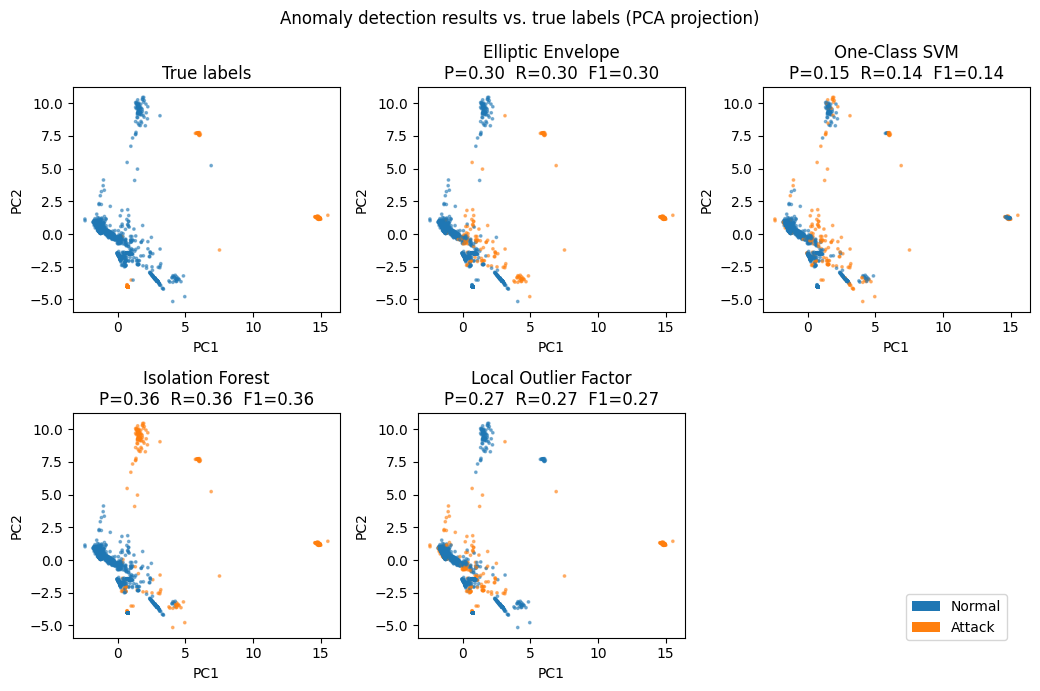

In [53]:
# Project to 2D for visualization
pca_vis = PCA(n_components=2, random_state=315)
X_vis = pca_vis.fit_transform(X_scaled)

# Convert sklearn's -1/1 output to 0/1 to compare against y_true
def to_binary(labels):
    return (np.array(labels) == -1).astype(int)

colors = {0: '#1f77b4', 1: '#ff7f0e'}

ncols = 3
nrows = 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 3.5, nrows * 3.5))
axes = axes.flatten()

model_data = [
    ('True labels', y_true.values, False),
    ('Elliptic Envelope', to_binary(elliptic_labels), True),
    ('One-Class SVM', to_binary(ocsvm_labels), True),
    ('Isolation Forest', to_binary(iso_forest_labels), True),
    ('Local Outlier Factor', to_binary(lof_labels), True),
]

for i, (name, labels, show_metrics) in enumerate(model_data):
    axes[i].scatter(X_vis[:, 0], X_vis[:, 1], c=[colors[l] for l in labels], s=3, alpha=0.5)
    if show_metrics:
        p = precision_score(y_true, labels, zero_division=0)
        r = recall_score(y_true, labels, zero_division=0)
        f = f1_score(y_true, labels, zero_division=0)
        axes[i].set_title(f'{name}\nP={p:.2f}  R={r:.2f}  F1={f:.2f}')
    else:
        axes[i].set_title(name)
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')

axes[5].set_visible(False)

legend_elements = [Patch(facecolor='#1f77b4', label='Normal'), Patch(facecolor='#ff7f0e', label='Attack')]
fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.97, 0.07))

fig.suptitle('Anomaly detection results vs. true labels (PCA projection)')
plt.tight_layout()
plt.show()

## 4. Association rule learning

### 4.1. Dataset

In [34]:
basket_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/market_basket.csv')
basket_df.head()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,item_11,item_12,item_13,item_14,item_15,item_16,item_17,item_18,item_19
0,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
basket_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   item_1   7500 non-null   str  
 1   item_2   5746 non-null   str  
 2   item_3   4388 non-null   str  
 3   item_4   3344 non-null   str  
 4   item_5   2528 non-null   str  
 5   item_6   1863 non-null   str  
 6   item_7   1368 non-null   str  
 7   item_8   980 non-null    str  
 8   item_9   653 non-null    str  
 9   item_10  394 non-null    str  
 10  item_11  255 non-null    str  
 11  item_12  153 non-null    str  
 12  item_13  86 non-null     str  
 13  item_14  46 non-null     str  
 14  item_15  24 non-null     str  
 15  item_16  7 non-null      str  
 16  item_17  3 non-null      str  
 17  item_18  3 non-null      str  
 18  item_19  2 non-null      str  
dtypes: str(19)
memory usage: 1.1 MB


In [36]:
basket = basket_df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()
basket[:5]

[['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'],
 ['low fat yogurt']]

### 4.2. Encode items

In [37]:
encoder = TransactionEncoder()
encoder.fit(basket)
transactions = encoder.transform(basket)
basket_df = pd.DataFrame(transactions, columns=encoder.columns_)
basket_df.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 4.3. Find association rules with Apriori

In [38]:
frequent_itemsets = apriori(basket_df, min_support=0.01, use_colnames=True)
frequent_itemsets.sort_values(by='support', ascending=False, inplace=True)
frequent_itemsets.reset_index(drop=True, inplace=True)
print(f'Number of frequent itemsets found: {len(frequent_itemsets)}')
frequent_itemsets.head()

Number of frequent itemsets found: 259


,support,itemsets
0,0.238267,frozenset({mineral water})
1,0.179733,frozenset({eggs})
2,0.174133,frozenset({spaghetti})
3,0.170933,frozenset({french fries})
4,0.163867,frozenset({chocolate})


In [54]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules.sort_values(by='confidence', ascending=False, inplace=True)
rules.reset_index(drop=True, inplace=True)

print(f'Number of association rules found: {len(rules)}')
rules.head(50)

Number of association rules found: 162


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"frozenset({ground beef, eggs})",frozenset({mineral water}),0.020000,0.238267,0.010133,0.506667,2.126469,1.0,0.005368,1.544054,0.540548,0.040838,0.352354,0.274598
1,"frozenset({ground beef, milk})",frozenset({mineral water}),0.022000,0.238267,0.011067,0.503030,2.111207,1.0,0.005825,1.532756,0.538177,0.044409,0.347580,0.274738
2,"frozenset({chocolate, ground beef})",frozenset({mineral water}),0.023067,0.238267,0.010933,0.473988,1.989319,1.0,0.005437,1.448130,0.509058,0.043663,0.309454,0.259938
3,"frozenset({frozen vegetables, milk})",frozenset({mineral water}),0.023600,0.238267,0.011067,0.468927,1.968075,1.0,0.005444,1.434328,0.503778,0.044125,0.302809,0.257687
4,frozenset({soup}),frozenset({mineral water}),0.050533,0.238267,0.023067,0.456464,1.915771,1.0,0.011026,1.401441,0.503458,0.086804,0.286449,0.276637
5,"frozenset({spaghetti, pancakes})",frozenset({mineral water}),0.025200,0.238267,0.011467,0.455026,1.909736,1.0,0.005462,1.397744,0.488682,0.045503,0.284561,0.251576
6,"frozenset({spaghetti, olive oil})",frozenset({mineral water}),0.022933,0.238267,0.010267,0.447674,1.878880,1.0,0.004802,1.379138,0.478747,0.040914,0.274910,0.245382
7,"frozenset({spaghetti, milk})",frozenset({mineral water}),0.035467,0.238267,0.015733,0.443609,1.861817,1.0,0.007283,1.369061,0.479911,0.060982,0.269572,0.254821
8,"frozenset({chocolate, milk})",frozenset({mineral water}),0.032133,0.238267,0.014000,0.435685,1.828559,1.0,0.006344,1.349836,0.468165,0.054602,0.259169,0.247221
9,"frozenset({ground beef, spaghetti})",frozenset({mineral water}),0.039200,0.238267,0.017067,0.435374,1.827256,1.0,0.007727,1.349094,0.471202,0.065540,0.258762,0.253501
